# Tutorial 5: SCMGenome and Multi-Objective Optimization

**Learning Objectives:**
- Understand Pareto dominance and multi-objective optimization
- Learn the NSGA-II algorithm
- Discover causal structure from data
- Balance competing objectives: fit, sparsity, simplicity

**Prerequisites:**
- Tutorial 01 (VectorGenome basics)
- Tutorial 02 (SequenceGenome/GP)
- Basic probability/statistics

**ML Practitioner Connection:**
- Multi-objective optimization = multi-task learning with Pareto solutions
- Crowding distance = diversity regularization
- Causal discovery = structure learning beyond correlation

## Part 1: Setup and Imports

In [52]:
# Core Python
import sys
import warnings
from dataclasses import dataclass, field
from typing import Any, List, Dict, Tuple, Optional
from random import Random
import copy
import json
import tempfile
import subprocess
from pathlib import Path

# Numerical computing and visualization
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from IPython.display import display, Image, Markdown

# Add project root to path
sys.path.insert(0, "../..")

# Evolve framework  
from evolve.representation.scm import SCMGenome
from evolve.representation.scm_decoder import SCMDecoder  
from evolve.evaluation.scm_evaluator import SCMEvaluator, SCMFitnessConfig
from evolve.core.callbacks import Callback
from evolve.experiment.checkpoint import CheckpointManager
from evolve.multiobjective import (
    MultiObjectiveFitness,
    dominates,
    pareto_front,
    crowding_distance,
    fast_non_dominated_sort,
    RankedIndividual,
    NSGA2Selector,
    hypervolume_2d,
)

# Tutorial utilities
from docs.tutorials.utils.tutorial_utils import (
    # Dataclasses
    EvolutionHistory,
    IslandConfig,
    
    # Visualization
    plot_fitness_history,
    compute_population_stats,
    
    # Terminology
    get_glossary,
    print_glossary_table,
    
    # Island model
    create_island_config,
    
    # GPU
    check_gpu_available,
)

# Mermaid diagram rendering (shared utility)
from docs.tutorials.utils.mermaid_renderer import (
    show_mermaid,
    DIAGRAM_DIR,
    setup_mermaid
)

# Check for plotly (optional for 3D visualization)
PLOTLY_AVAILABLE = False
try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    pass

# Suppress warnings
warnings.filterwarnings('ignore')

# Setup mermaid rendering
setup_mermaid(check_installation=True)

print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Plotly available: {PLOTLY_AVAILABLE}")

✅ Mermaid CLI ready
✅ All imports successful!
NumPy version: 2.4.2
Plotly available: True


## Part 2: EA Primer - Multi-Objective Optimization (FR-012)

### Single vs Multi-Objective

| Aspect | Single-Objective | Multi-Objective |
|--------|------------------|------------------|
| Solution | One optimal point | Set of Pareto-optimal solutions |
| Comparison | Total ordering (better/worse) | Partial ordering (dominates/not) |
| Output | One best | Pareto front (trade-off curve) |
| Selection | Rank by fitness | Rank by Pareto front + crowding |

### Key Insight

**Weighted Sum**: `fitness = w₁*f₁ + w₂*f₂` → Single solution, must choose weights

**Multi-Objective**: Find ALL solutions where improving one objective requires worsening another

## 🧬 Multi-Objective Terminology

| MO Term | ML Analogy |
|------------------------|-------------------------------------|
| **Pareto Dominance** | One solution better on ALL metrics |
| **Pareto Front** | Trade-off curve / efficient frontier |
| **Non-dominated** | No solution beats it on all objectives |
| **Crowding Distance** | Diversity regularization term |
| **NSGA-II** | Multi-objective GA with Pareto ranking |
| **Hypervolume** | Quality metric for Pareto fronts |
| **Objective Space** | All possible (f1, f2, ...) combinations |
| **Decision Space** | Parameter/genome space |
| **Constraint Violation** | Infeasibility penalty |

## Part 3: Mermaid Diagrams - Multi-Objective Concepts (FR-014)

Rule: A dominates B iff A ≥ B on ALL objectives AND A > B on at least one

📊 Pareto Dominance



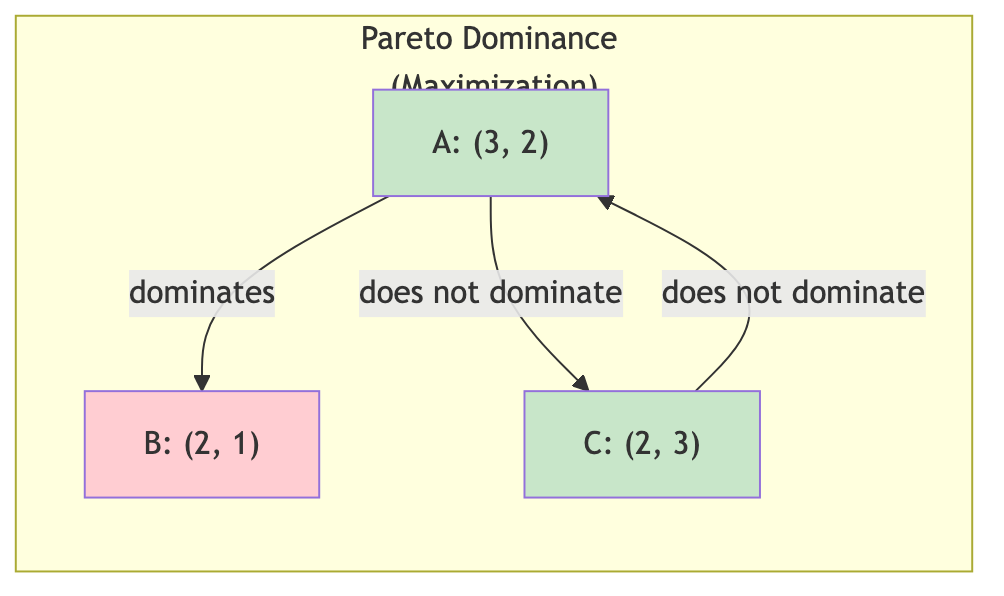

In [53]:
# Test with Pareto Dominance diagram
PARETO_DOMINANCE_DIAGRAM = """
graph LR
    subgraph Dominance["Pareto Dominance (Maximization)"]
        A["A: (3, 2)"] -->|dominates| B["B: (2, 1)"]
        A -->|does not dominate| C["C: (2, 3)"]
        C -->|does not dominate| A
    end
    
    style A fill:#c8e6c9
    style C fill:#c8e6c9
    style B fill:#ffcdd2
"""

print("Rule: A dominates B iff A ≥ B on ALL objectives AND A > B on at least one\n")
show_mermaid(PARETO_DOMINANCE_DIAGRAM, "pareto_dominance", "Pareto Dominance")

📊 NSGA-II Algorithm Flow



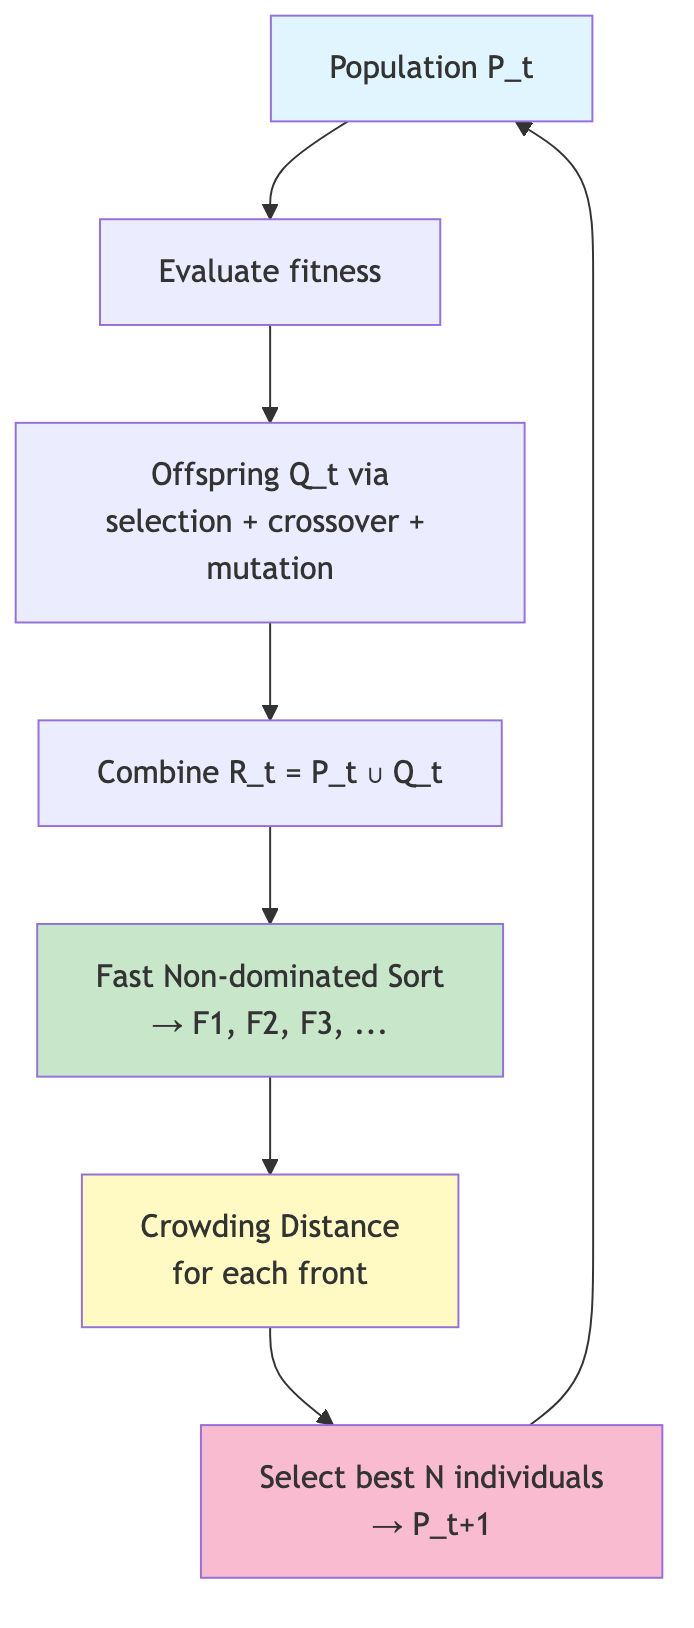

In [54]:
# Diagram 2: NSGA-II Flow
NSGA2_FLOW_DIAGRAM = """
graph TD
    P[Population P_t] --> E[Evaluate fitness]
    E --> O[Offspring Q_t via\nselection + crossover + mutation]
    O --> C[Combine R_t = P_t ∪ Q_t]
    C --> F[Fast Non-dominated Sort\n→ F1, F2, F3, ...]
    F --> CD[Crowding Distance\nfor each front]
    CD --> S[Select best N individuals\n→ P_t+1]
    S --> P
    
    style P fill:#e1f5fe
    style F fill:#c8e6c9
    style CD fill:#fff9c4
    style S fill:#f8bbd0
"""

show_mermaid(NSGA2_FLOW_DIAGRAM, "nsga2_flow", "NSGA-II Algorithm Flow")

📊 SCM Genome → Causal Graph → Fitness



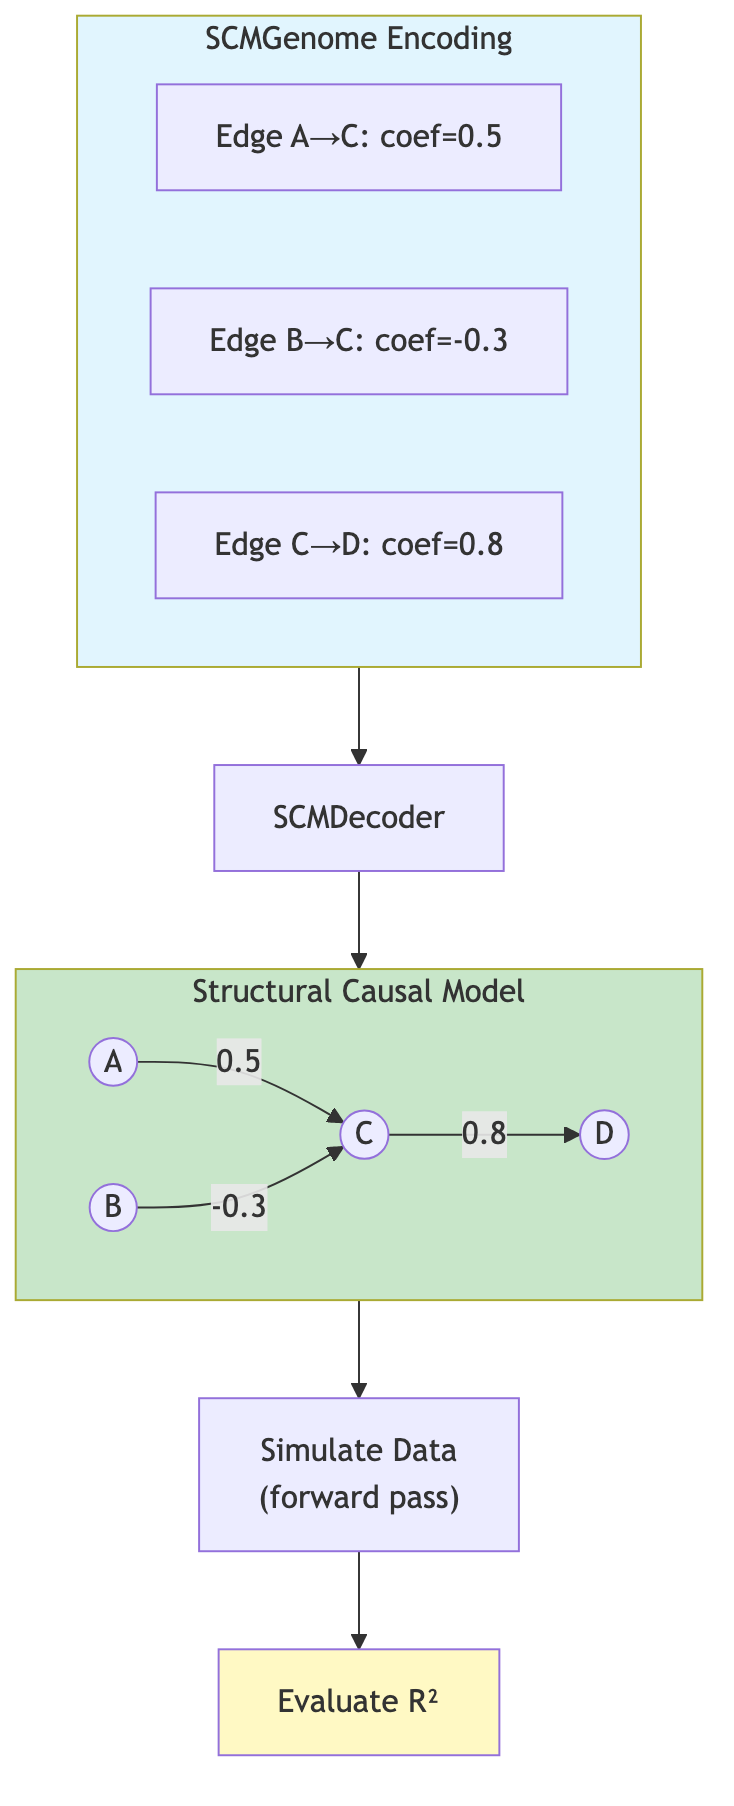

In [55]:
# Diagram 3: SCM Encoding in Genome
SCM_ENCODING_DIAGRAM = """
graph TD
    subgraph Genome["SCMGenome Encoding"]
        E1[Edge A→C: coef=0.5]
        E2[Edge B→C: coef=-0.3]
        E3[Edge C→D: coef=0.8]
    end
    
    subgraph SCM["Structural Causal Model"]
        A((A)) -->|0.5| C((C))
        B((B)) -->|-0.3| C
        C -->|0.8| D((D))
    end
    
    Genome --> Decode[SCMDecoder]
    Decode --> SCM
    
    SCM --> Data["Simulate Data\n(forward pass)"]
    Data --> Fit["Evaluate R²"]
    
    style Genome fill:#e1f5fe
    style SCM fill:#c8e6c9
    style Fit fill:#fff9c4
"""

show_mermaid(SCM_ENCODING_DIAGRAM, "scm_encoding", "SCM Genome → Causal Graph → Fitness")

## Part 4: Problem Setup - Causal Discovery

In [56]:
# Generate synthetic data from a known causal structure
def generate_scm_data(
    n_samples: int = 1000,
    seed: int = 42
) -> Tuple[np.ndarray, Dict[str, List[str]]]:
    """
    Generate data from a 5-variable causal model.
    
    True structure:
        A → C
        B → C
        C → D
        C → E
        
    Returns:
        data: Array of shape (n_samples, 5)
        true_edges: Dict mapping child → list of parents
    """
    rng = np.random.default_rng(seed)
    
    # Exogenous noise
    noise_A = rng.normal(0, 1, n_samples)
    noise_B = rng.normal(0, 1, n_samples)
    noise_C = rng.normal(0, 0.5, n_samples)
    noise_D = rng.normal(0, 0.5, n_samples)
    noise_E = rng.normal(0, 0.5, n_samples)
    
    # Causal equations
    A = noise_A
    B = noise_B
    C = 0.7 * A + 0.5 * B + noise_C
    D = 0.8 * C + noise_D
    E = -0.6 * C + noise_E
    
    data = np.column_stack([A, B, C, D, E])
    
    true_edges = {
        'A': [],
        'B': [],
        'C': ['A', 'B'],
        'D': ['C'],
        'E': ['C'],
    }
    
    return data, true_edges

# Generate data
data, true_edges = generate_scm_data(n_samples=1000)
VARIABLES = ['A', 'B', 'C', 'D', 'E']

print("📊 Causal Discovery Problem")
print("=" * 50)
print(f"Variables: {VARIABLES}")
print(f"Samples: {data.shape[0]}")
print(f"\nTrue Causal Structure:")
for var, parents in true_edges.items():
    if parents:
        print(f"   {var} ← {', '.join(parents)}")
    else:
        print(f"   {var} ← (root)")

📊 Causal Discovery Problem
Variables: ['A', 'B', 'C', 'D', 'E']
Samples: 1000

True Causal Structure:
   A ← (root)
   B ← (root)
   C ← A, B
   D ← C
   E ← C


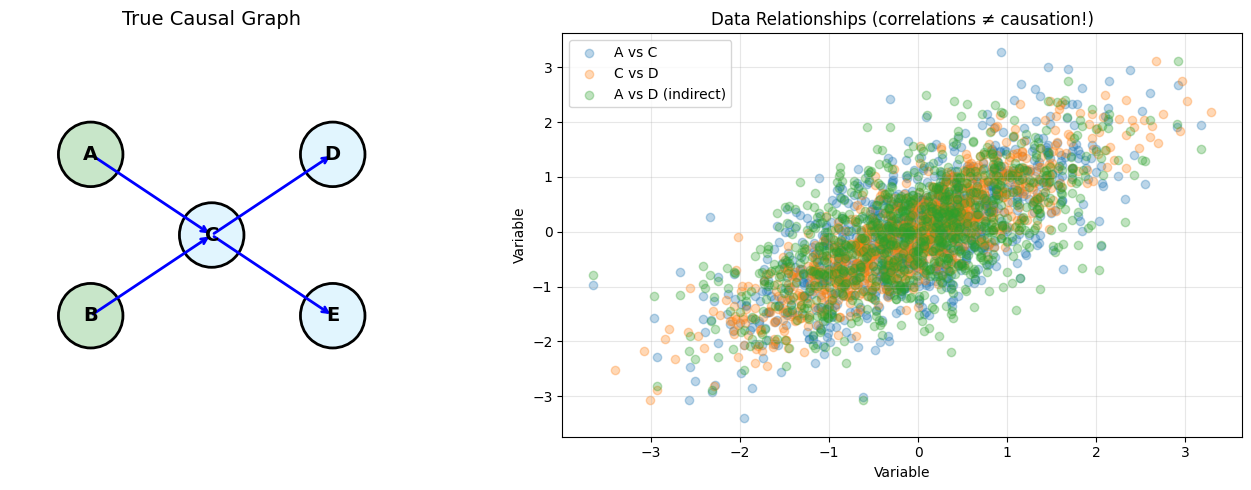

In [57]:
# Visualize true causal graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph structure
ax1 = axes[0]
positions = {
    'A': (0.2, 0.7),
    'B': (0.2, 0.3),
    'C': (0.5, 0.5),
    'D': (0.8, 0.7),
    'E': (0.8, 0.3),
}

# Draw edges
edges = [('A', 'C'), ('B', 'C'), ('C', 'D'), ('C', 'E')]
for src, dst in edges:
    ax1.annotate('', xy=positions[dst], xytext=positions[src],
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Draw nodes
for var, pos in positions.items():
    color = '#c8e6c9' if not true_edges[var] else '#e1f5fe'
    circle = plt.Circle(pos, 0.08, facecolor=color, edgecolor='black', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(pos[0], pos[1], var, ha='center', va='center', fontsize=14, fontweight='bold')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('True Causal Graph', fontsize=14)

# Scatter plots showing correlations
ax2 = axes[1]
ax2.scatter(data[:, 0], data[:, 2], alpha=0.3, label='A vs C')
ax2.scatter(data[:, 2], data[:, 3], alpha=0.3, label='C vs D')
ax2.scatter(data[:, 0], data[:, 3], alpha=0.3, label='A vs D (indirect)')
ax2.set_xlabel('Variable')
ax2.set_ylabel('Variable')
ax2.set_title('Data Relationships (correlations ≠ causation!)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Pareto Dominance (FR-048)

In [58]:
# Demonstrate Pareto dominance
def demo_dominance():
    """Demonstrate Pareto dominance relationships."""
    # Create example fitnesses (maximization)
    fitnesses = [
        MultiObjectiveFitness(np.array([3.0, 2.0])),  # A
        MultiObjectiveFitness(np.array([2.0, 3.0])),  # B
        MultiObjectiveFitness(np.array([2.0, 2.0])),  # C (dominated)
        MultiObjectiveFitness(np.array([1.0, 1.0])),  # D (dominated)
    ]
    labels = ['A', 'B', 'C', 'D']
    
    print("📊 Pareto Dominance Examples")
    print("=" * 50)
    print("\nSolutions (maximizing both f1 and f2):")
    for label, f in zip(labels, fitnesses):
        print(f"   {label}: ({f.objectives[0]:.1f}, {f.objectives[1]:.1f})")
    
    print("\nDominance relations:")
    for i, (label_i, f_i) in enumerate(zip(labels, fitnesses)):
        for j, (label_j, f_j) in enumerate(zip(labels, fitnesses)):
            if i != j and dominates(f_i, f_j):
                print(f"   {label_i} dominates {label_j}")
    
    # Find Pareto front
    front_indices = pareto_front(fitnesses)
    front_labels = [labels[i] for i in front_indices]
    print(f"\nPareto front: {front_labels}")
    
    return fitnesses, labels, front_indices

fitnesses, labels, front_indices = demo_dominance()

📊 Pareto Dominance Examples

Solutions (maximizing both f1 and f2):
   A: (3.0, 2.0)
   B: (2.0, 3.0)
   C: (2.0, 2.0)
   D: (1.0, 1.0)

Dominance relations:
   A dominates C
   A dominates D
   B dominates C
   B dominates D
   C dominates D

Pareto front: ['A', 'B']


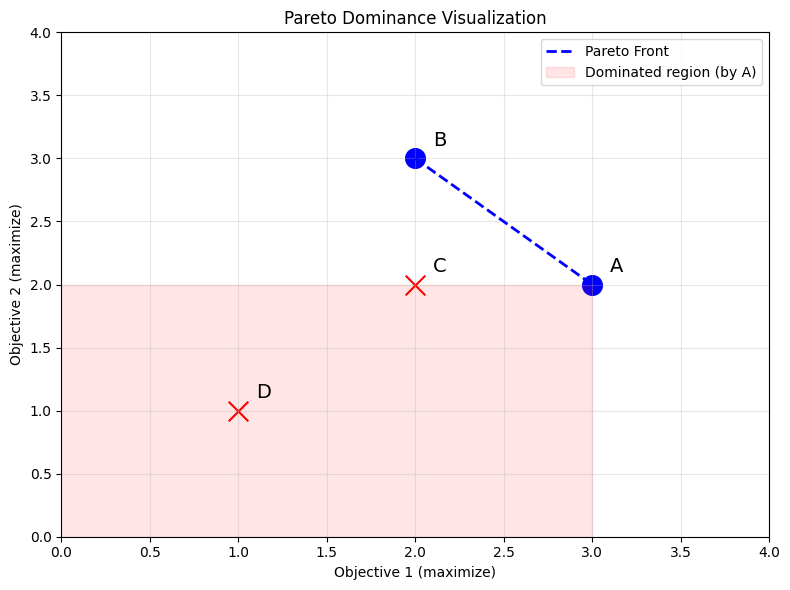

In [59]:
# Visualize Pareto front
fig, ax = plt.subplots(figsize=(8, 6))

for i, (f, label) in enumerate(zip(fitnesses, labels)):
    color = 'blue' if i in front_indices else 'red'
    marker = 'o' if i in front_indices else 'x'
    ax.scatter(f.objectives[0], f.objectives[1], s=200, c=color, marker=marker)
    ax.annotate(label, (f.objectives[0] + 0.1, f.objectives[1] + 0.1), fontsize=14)

# Draw Pareto front line
front_points = [fitnesses[i].objectives for i in sorted(front_indices, key=lambda i: fitnesses[i].objectives[0])]
if len(front_points) > 1:
    ax.plot([p[0] for p in front_points], [p[1] for p in front_points], 
            'b--', linewidth=2, label='Pareto Front')

# Dominance region
ax.fill_between([0, 3], [0, 0], [2, 2], alpha=0.1, color='red', 
                label='Dominated region (by A)')

ax.set_xlabel('Objective 1 (maximize)')
ax.set_ylabel('Objective 2 (maximize)')
ax.set_title('Pareto Dominance Visualization')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

## Part 6: Crowding Distance (FR-049)

In [60]:
# Demonstrate crowding distance
def demo_crowding_distance():
    """Demonstrate crowding distance calculation."""
    # Create a Pareto front with 5 solutions
    fitnesses = [
        MultiObjectiveFitness(np.array([5.0, 1.0])),  # Boundary
        MultiObjectiveFitness(np.array([4.0, 2.0])),  # Interior
        MultiObjectiveFitness(np.array([3.0, 3.0])),  # Interior
        MultiObjectiveFitness(np.array([2.0, 4.0])),  # Interior
        MultiObjectiveFitness(np.array([1.0, 5.0])),  # Boundary
    ]
    
    front_indices = list(range(len(fitnesses)))  # All on front
    distances = crowding_distance(fitnesses, front_indices)
    
    print("📊 Crowding Distance")
    print("=" * 50)
    print("\nSolutions on Pareto front:")
    for i, f in enumerate(fitnesses):
        dist = distances[i]
        dist_str = '∞' if dist == float('inf') else f'{dist:.2f}'
        print(f"   {i}: ({f.objectives[0]:.1f}, {f.objectives[1]:.1f}) → crowding = {dist_str}")
    
    print("\n💡 Insight:")
    print("   - Boundary solutions get infinite distance (always preserved)")
    print("   - Interior solutions: distance based on neighbor spacing")
    print("   - Higher crowding = more isolated = more valuable for diversity")
    
    return fitnesses, distances

cd_fitnesses, cd_distances = demo_crowding_distance()

📊 Crowding Distance

Solutions on Pareto front:
   0: (5.0, 1.0) → crowding = ∞
   1: (4.0, 2.0) → crowding = 1.00
   2: (3.0, 3.0) → crowding = 1.00
   3: (2.0, 4.0) → crowding = 1.00
   4: (1.0, 5.0) → crowding = ∞

💡 Insight:
   - Boundary solutions get infinite distance (always preserved)
   - Interior solutions: distance based on neighbor spacing
   - Higher crowding = more isolated = more valuable for diversity


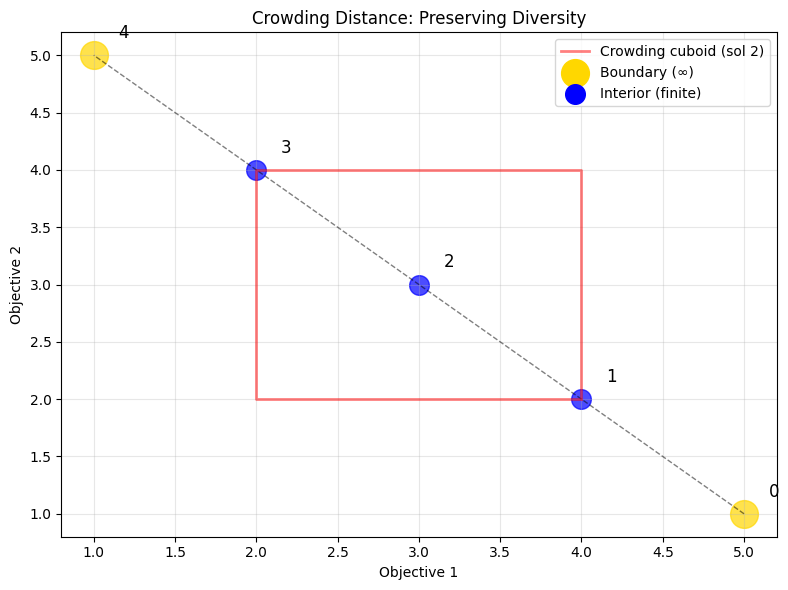

In [61]:
# Visualize crowding distance
fig, ax = plt.subplots(figsize=(8, 6))

# Plot solutions with crowding-based size
for i, f in enumerate(cd_fitnesses):
    dist = cd_distances[i]
    if dist == float('inf'):
        size = 400
        color = 'gold'
    else:
        size = 100 + dist * 100
        color = 'blue'
    ax.scatter(f.objectives[0], f.objectives[1], s=size, c=color, alpha=0.7)
    ax.annotate(f'{i}', (f.objectives[0] + 0.15, f.objectives[1] + 0.15), fontsize=12)

# Connect front
points = [f.objectives for f in cd_fitnesses]
ax.plot([p[0] for p in points], [p[1] for p in points], 'k--', linewidth=1, alpha=0.5)

# Show crowding cuboid for solution 2
x_prev, y_prev = cd_fitnesses[1].objectives
x_next, y_next = cd_fitnesses[3].objectives
x_curr, y_curr = cd_fitnesses[2].objectives
ax.plot([x_prev, x_prev, x_next, x_next, x_prev], 
        [y_prev, y_next, y_next, y_prev, y_prev], 
        'r-', linewidth=2, alpha=0.5, label='Crowding cuboid (sol 2)')

ax.scatter([], [], s=400, c='gold', label='Boundary (∞)')
ax.scatter([], [], s=200, c='blue', label='Interior (finite)')

ax.set_xlabel('Objective 1')
ax.set_ylabel('Objective 2')
ax.set_title('Crowding Distance: Preserving Diversity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 7: NSGA-II Algorithm (FR-047)

In [62]:
# Demonstrate NSGA-II non-dominated sorting
def demo_nsga2_sorting():
    """Demonstrate NSGA-II non-dominated sorting."""
    # Create population with multiple fronts
    fitnesses = [
        # Front 0 (Pareto front)
        MultiObjectiveFitness(np.array([5.0, 1.0])),
        MultiObjectiveFitness(np.array([3.0, 3.0])),
        MultiObjectiveFitness(np.array([1.0, 5.0])),
        # Front 1
        MultiObjectiveFitness(np.array([3.0, 1.0])),
        MultiObjectiveFitness(np.array([2.0, 2.0])),
        MultiObjectiveFitness(np.array([1.0, 3.0])),
        # Front 2
        MultiObjectiveFitness(np.array([1.0, 1.0])),
        MultiObjectiveFitness(np.array([0.5, 1.5])),
    ]
    
    fronts = fast_non_dominated_sort(fitnesses)
    
    print("📊 NSGA-II Non-Dominated Sorting")
    print("=" * 50)
    print(f"\nPopulation size: {len(fitnesses)}")
    print(f"Number of fronts: {len(fronts)}")
    
    for rank, front in enumerate(fronts):
        print(f"\nFront {rank}:")
        for idx in front:
            f = fitnesses[idx]
            print(f"   Solution {idx}: ({f.objectives[0]:.1f}, {f.objectives[1]:.1f})")
    
    return fitnesses, fronts

nsga_fitnesses, fronts = demo_nsga2_sorting()

📊 NSGA-II Non-Dominated Sorting

Population size: 8
Number of fronts: 3

Front 0:
   Solution 0: (5.0, 1.0)
   Solution 1: (3.0, 3.0)
   Solution 2: (1.0, 5.0)

Front 1:
   Solution 3: (3.0, 1.0)
   Solution 4: (2.0, 2.0)
   Solution 5: (1.0, 3.0)

Front 2:
   Solution 6: (1.0, 1.0)
   Solution 7: (0.5, 1.5)


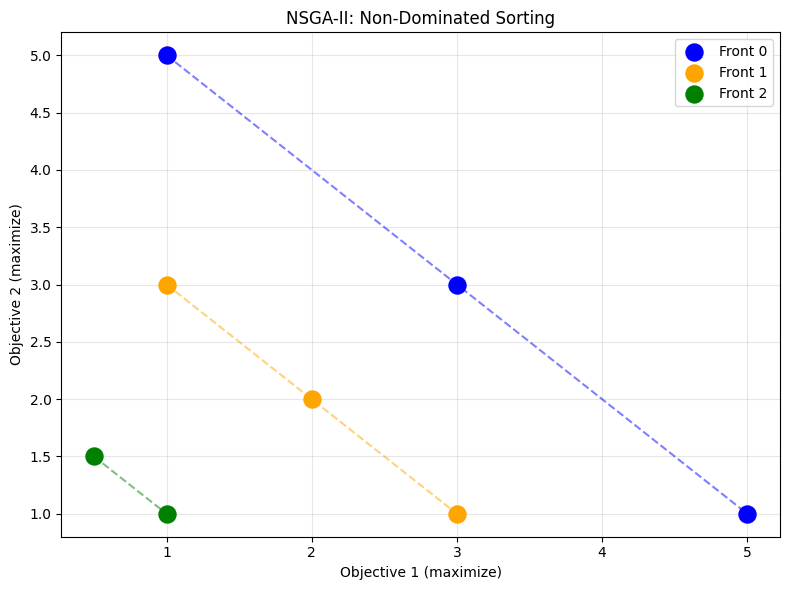

In [63]:
# Visualize fronts
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['blue', 'orange', 'green', 'red']

for rank, front in enumerate(fronts):
    points = [nsga_fitnesses[i].objectives for i in front]
    points_sorted = sorted(points, key=lambda p: p[0])
    
    xs = [p[0] for p in points_sorted]
    ys = [p[1] for p in points_sorted]
    
    ax.scatter(xs, ys, c=colors[rank % len(colors)], s=150, 
               label=f'Front {rank}', zorder=3)
    ax.plot(xs, ys, c=colors[rank % len(colors)], linestyle='--', alpha=0.5)

ax.set_xlabel('Objective 1 (maximize)')
ax.set_ylabel('Objective 2 (maximize)')
ax.set_title('NSGA-II: Non-Dominated Sorting')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 8: Three Objectives for Causal Discovery (FR-051)

In [64]:
@dataclass
class CausalGraph:
    """
    Represents a causal graph (DAG).
    
    Attributes:
        variables: List of variable names
        edges: Dict mapping child → list of parents
        coefficients: Dict mapping (parent, child) → coefficient
    """
    variables: List[str]
    edges: Dict[str, List[str]] = field(default_factory=dict)
    coefficients: Dict[Tuple[str, str], float] = field(default_factory=dict)
    
    @property
    def n_edges(self) -> int:
        """Total number of edges."""
        return sum(len(parents) for parents in self.edges.values())
    
    @property
    def n_nodes(self) -> int:
        """Number of nodes with at least one edge."""
        active = set()
        for child, parents in self.edges.items():
            if parents:
                active.add(child)
                active.update(parents)
        return len(active)

def evaluate_causal_graph(
    graph: CausalGraph, 
    data: np.ndarray,
    variables: List[str]
) -> MultiObjectiveFitness:
    """
    Evaluate a causal graph on three objectives.
    
    Objectives (all to maximize):
    1. Data fit: Average R² across all child variables
    2. Sparsity: -n_edges (negative so we maximize = fewer edges)
    3. Simplicity: -total_coefficients (simpler = better)
    
    Returns:
        MultiObjectiveFitness with 3 objectives
    """
    var_to_idx = {v: i for i, v in enumerate(variables)}
    
    # Objective 1: Data fit (R² averaged over all equations)
    r2_scores = []
    for child, parents in graph.edges.items():
        if not parents:
            continue
        
        y = data[:, var_to_idx[child]]
        X = np.column_stack([data[:, var_to_idx[p]] for p in parents])
        
        # Simple linear regression
        try:
            coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            y_pred = X @ coeffs
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
            r2_scores.append(max(0, r2))
        except:
            r2_scores.append(0.0)
    
    data_fit = np.mean(r2_scores) if r2_scores else 0.0
    
    # Objective 2: Sparsity (negative edges, so maximize = fewer)
    sparsity = -graph.n_edges
    
    # Objective 3: Simplicity (negative complexity)
    # Complexity = total absolute coefficient magnitudes
    complexity = sum(abs(c) for c in graph.coefficients.values()) if graph.coefficients else graph.n_edges
    simplicity = -complexity
    
    return MultiObjectiveFitness(np.array([data_fit, sparsity, simplicity]))

print("📊 Three Objectives for Causal Discovery")
print("=" * 50)
print("\n1. DATA FIT (maximize R²)")
print("   - How well do the causal equations explain the data?")
print("   - Higher = better fit, but beware overfitting!")
print("\n2. SPARSITY (minimize edges)")
print("   - Prefer simpler graphs with fewer edges")
print("   - Occam's razor: simpler explanations preferred")
print("\n3. SIMPLICITY (minimize total coefficients)")
print("   - Prefer smaller coefficient magnitudes")
print("   - Related to L1/L2 regularization")

📊 Three Objectives for Causal Discovery

1. DATA FIT (maximize R²)
   - How well do the causal equations explain the data?
   - Higher = better fit, but beware overfitting!

2. SPARSITY (minimize edges)
   - Prefer simpler graphs with fewer edges
   - Occam's razor: simpler explanations preferred

3. SIMPLICITY (minimize total coefficients)
   - Prefer smaller coefficient magnitudes
   - Related to L1/L2 regularization


## Part 9: Running Multi-Objective Evolution

In [65]:
class NSGA2Evolver:
    """
    NSGA-II for causal discovery.
    """
    def __init__(
        self,
        variables: List[str],
        data: np.ndarray,
        pop_size: int = 50,
        max_generations: int = 30,
        mutation_rate: float = 0.3,
        seed: int = 42,
    ):
        self.variables = variables
        self.data = data
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.mutation_rate = mutation_rate
        self.rng = np.random.default_rng(seed)
        
        self.history = {
            'pareto_fronts': [],
            'hypervolume': [],
            'best_r2': [],
        }
    
    def random_graph(self) -> CausalGraph:
        """Generate random causal graph (DAG)."""
        edges = {v: [] for v in self.variables}
        coefficients = {}
        
        # Random edges (respecting topological order to ensure DAG)
        for i, child in enumerate(self.variables):
            # Can only have parents from earlier variables
            potential_parents = self.variables[:i]
            if potential_parents:
                n_parents = self.rng.integers(0, min(3, len(potential_parents)) + 1)
                if n_parents > 0:
                    parents = self.rng.choice(potential_parents, n_parents, replace=False).tolist()
                    edges[child] = parents
                    for p in parents:
                        coefficients[(p, child)] = self.rng.uniform(-2, 2)
        
        return CausalGraph(variables=self.variables, edges=edges, coefficients=coefficients)
    
    def mutate(self, graph: CausalGraph) -> CausalGraph:
        """Mutate causal graph (add/remove edge, change coefficient)."""
        edges = {k: list(v) for k, v in graph.edges.items()}
        coefficients = dict(graph.coefficients)
        
        mutation_type = self.rng.choice(['add', 'remove', 'coefficient'])
        
        if mutation_type == 'add':
            # Add random edge
            for i, child in enumerate(self.variables):
                potential_parents = [p for p in self.variables[:i] if p not in edges[child]]
                if potential_parents and self.rng.random() < 0.3:
                    parent = self.rng.choice(potential_parents)
                    edges[child].append(parent)
                    coefficients[(parent, child)] = self.rng.uniform(-2, 2)
                    break
        
        elif mutation_type == 'remove':
            # Remove random edge
            for child in self.variables:
                if edges[child] and self.rng.random() < 0.3:
                    parent = self.rng.choice(edges[child])
                    edges[child].remove(parent)
                    coefficients.pop((parent, child), None)
                    break
        
        else:
            # Mutate coefficient
            if coefficients:
                keys = list(coefficients.keys())
                key = keys[self.rng.integers(0, len(keys))]
                coefficients[key] += self.rng.normal(0, 0.5)
        
        return CausalGraph(variables=self.variables, edges=edges, coefficients=coefficients)
    
    def crossover(self, parent1: CausalGraph, parent2: CausalGraph) -> CausalGraph:
        """Uniform crossover on edges."""
        edges = {v: [] for v in self.variables}
        coefficients = {}
        
        for var in self.variables:
            if self.rng.random() < 0.5:
                edges[var] = list(parent1.edges.get(var, []))
                for p in edges[var]:
                    coefficients[(p, var)] = parent1.coefficients.get((p, var), 0.5)
            else:
                edges[var] = list(parent2.edges.get(var, []))
                for p in edges[var]:
                    coefficients[(p, var)] = parent2.coefficients.get((p, var), 0.5)
        
        return CausalGraph(variables=self.variables, edges=edges, coefficients=coefficients)
    
    def evolve(self) -> List[CausalGraph]:
        """Run NSGA-II evolution."""
        # Initialize population
        population = [self.random_graph() for _ in range(self.pop_size)]
        
        for gen in range(self.max_generations):
            # Evaluate
            fitnesses = [evaluate_causal_graph(g, self.data, self.variables) 
                        for g in population]
            
            # Non-dominated sorting
            fronts = fast_non_dominated_sort(fitnesses)
            
            # Calculate crowding distance for each front
            all_ranked = []
            for rank, front in enumerate(fronts):
                distances = crowding_distance(fitnesses, front)
                for idx in front:
                    all_ranked.append(RankedIndividual(idx, rank, distances[idx]))
            
            # Sort by rank, then crowding
            all_ranked.sort()
            
            # Track history
            pareto_fitnesses = [fitnesses[i] for i in fronts[0]]
            self.history['pareto_fronts'].append(pareto_fitnesses)
            self.history['best_r2'].append(max(f.objectives[0] for f in fitnesses))
            
            # Calculate hypervolume (2D projection: R² vs Sparsity)
            if len(fronts[0]) > 1:
                # Extract 2D projection (objectives 0 and 1)
                points_2d = np.array([[fitnesses[i].objectives[0], fitnesses[i].objectives[1]] 
                                      for i in fronts[0]])
                hv = hypervolume_2d(points_2d, reference=np.array([0.0, -10.0]))
                self.history['hypervolume'].append(hv)
            else:
                self.history['hypervolume'].append(0.0)
            
            # Progress
            if gen % 5 == 0:
                best_fit = max(f.objectives[0] for f in fitnesses)
                print(f"Gen {gen:3d}: Pareto size={len(fronts[0])}, Best R²={best_fit:.4f}")
            
            # Selection for next generation
            selected_indices = [r.index for r in all_ranked[:self.pop_size]]
            
            # Create offspring
            new_population = []
            
            # Elitism: keep best from front 0
            for idx in fronts[0][:min(5, len(fronts[0]))]:
                new_population.append(population[idx])
            
            # Fill rest with offspring
            while len(new_population) < self.pop_size:
                p1_idx = self.rng.choice(selected_indices[:len(selected_indices)//2])
                p2_idx = self.rng.choice(selected_indices[:len(selected_indices)//2])
                
                child = self.crossover(population[p1_idx], population[p2_idx])
                if self.rng.random() < self.mutation_rate:
                    child = self.mutate(child)
                new_population.append(child)
            
            population = new_population[:self.pop_size]
        
        # Return final Pareto front
        fitnesses = [evaluate_causal_graph(g, self.data, self.variables) 
                    for g in population]
        fronts = fast_non_dominated_sort(fitnesses)
        return [population[i] for i in fronts[0]]

print("✅ NSGA2Evolver class defined")

✅ NSGA2Evolver class defined


In [66]:
# Run NSGA-II evolution
print("🧬 NSGA-II for Causal Discovery")
print("=" * 50)

evolver = NSGA2Evolver(
    variables=VARIABLES,
    data=data,
    pop_size=50,
    max_generations=30,
    mutation_rate=0.3,
    seed=42
)

pareto_graphs = evolver.evolve()

print(f"\n🏆 Final Pareto front: {len(pareto_graphs)} solutions")

🧬 NSGA-II for Causal Discovery
Gen   0: Pareto size=5, Best R²=0.7411
Gen   5: Pareto size=43, Best R²=0.7411
Gen  10: Pareto size=48, Best R²=0.7411
Gen  15: Pareto size=42, Best R²=0.7411
Gen  20: Pareto size=45, Best R²=0.7411
Gen  25: Pareto size=43, Best R²=0.7411

🏆 Final Pareto front: 45 solutions


## Part 10: Pareto Front Visualization (FR-050)

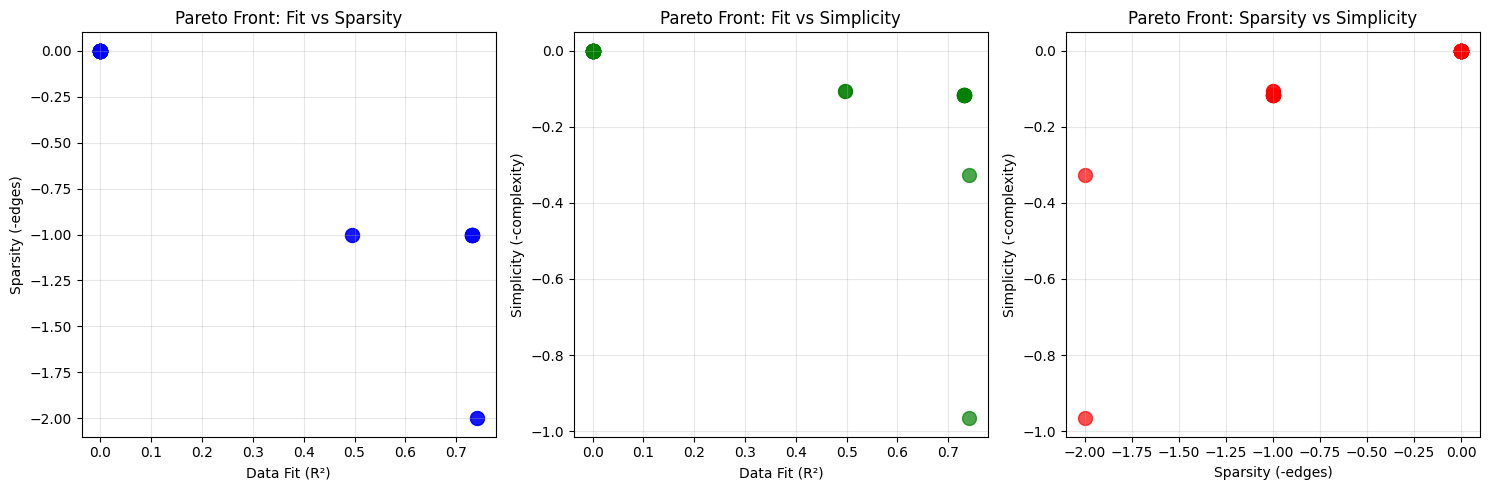

In [67]:
# Evaluate final Pareto front
pareto_fitnesses = [evaluate_causal_graph(g, data, VARIABLES) for g in pareto_graphs]

# 2D projections
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² vs Sparsity
axes[0].scatter(
    [f.objectives[0] for f in pareto_fitnesses],
    [f.objectives[1] for f in pareto_fitnesses],
    s=100, c='blue', alpha=0.7
)
axes[0].set_xlabel('Data Fit (R²)')
axes[0].set_ylabel('Sparsity (-edges)')
axes[0].set_title('Pareto Front: Fit vs Sparsity')
axes[0].grid(True, alpha=0.3)

# R² vs Simplicity
axes[1].scatter(
    [f.objectives[0] for f in pareto_fitnesses],
    [f.objectives[2] for f in pareto_fitnesses],
    s=100, c='green', alpha=0.7
)
axes[1].set_xlabel('Data Fit (R²)')
axes[1].set_ylabel('Simplicity (-complexity)')
axes[1].set_title('Pareto Front: Fit vs Simplicity')
axes[1].grid(True, alpha=0.3)

# Sparsity vs Simplicity
axes[2].scatter(
    [f.objectives[1] for f in pareto_fitnesses],
    [f.objectives[2] for f in pareto_fitnesses],
    s=100, c='red', alpha=0.7
)
axes[2].set_xlabel('Sparsity (-edges)')
axes[2].set_ylabel('Simplicity (-complexity)')
axes[2].set_title('Pareto Front: Sparsity vs Simplicity')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# 3D Pareto front (if plotly available)
if PLOTLY_AVAILABLE:
    fig = go.Figure(data=[go.Scatter3d(
        x=[f.objectives[0] for f in pareto_fitnesses],
        y=[f.objectives[1] for f in pareto_fitnesses],
        z=[f.objectives[2] for f in pareto_fitnesses],
        mode='markers',
        marker=dict(
            size=8,
            color=[f.objectives[0] for f in pareto_fitnesses],
            colorscale='Viridis',
            opacity=0.8
        )
    )])
    
    fig.update_layout(
        title='3D Pareto Front (FR-048)',
        scene=dict(
            xaxis_title='Data Fit (R²)',
            yaxis_title='Sparsity (-edges)',
            zaxis_title='Simplicity (-complexity)'
        )
    )
    fig.show()
else:
    print("ℹ️ Install plotly for interactive 3D visualization")
    print("   pip install plotly")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Part 11: Weighted-Sum vs Multi-Objective (FR-052)

In [69]:
# Compare weighted-sum approach
print("📊 Weighted-Sum vs Multi-Objective Comparison")
print("=" * 50)

def weighted_sum_fitness(graph: CausalGraph, weights: Tuple[float, float, float]) -> float:
    """Compute weighted sum of objectives."""
    f = evaluate_causal_graph(graph, data, VARIABLES)
    return weights[0] * f.objectives[0] + weights[1] * f.objectives[1] + weights[2] * f.objectives[2]

# Different weight combinations
weight_configs = [
    (1.0, 0.0, 0.0, "Fit only"),
    (0.0, 1.0, 0.0, "Sparsity only"),
    (0.5, 0.3, 0.2, "Balanced"),
    (0.8, 0.1, 0.1, "Fit-focused"),
]

print("\nWeighted-Sum Results:")
for w1, w2, w3, name in weight_configs:
    # Find best from Pareto front under these weights
    scores = [weighted_sum_fitness(g, (w1, w2, w3)) for g in pareto_graphs]
    best_idx = np.argmax(scores)
    best = pareto_graphs[best_idx]
    f = evaluate_causal_graph(best, data, VARIABLES)
    print(f"   {name}: R²={f.objectives[0]:.3f}, Edges={-int(f.objectives[1])}, Selected from Pareto")

print("\n💡 Insight:")
print("   - Weighted-sum requires choosing weights a priori")
print("   - Multi-objective gives full trade-off curve")
print("   - Decision maker picks from Pareto front AFTER evolution")

📊 Weighted-Sum vs Multi-Objective Comparison

Weighted-Sum Results:
   Fit only: R²=0.741, Edges=2, Selected from Pareto
   Sparsity only: R²=0.000, Edges=0, Selected from Pareto
   Balanced: R²=0.732, Edges=1, Selected from Pareto
   Fit-focused: R²=0.732, Edges=1, Selected from Pareto

💡 Insight:
   - Weighted-sum requires choosing weights a priori
   - Multi-objective gives full trade-off curve
   - Decision maker picks from Pareto front AFTER evolution


## Part 12: Causal Graph Evaluation (FR-054)

In [70]:
def compare_graphs(discovered: CausalGraph, true_edges: Dict[str, List[str]]) -> Dict[str, Any]:
    """
    Compare discovered graph to ground truth.
    
    Returns:
        Dict with precision, recall, F1, edge-level details
    """
    # Convert to edge sets
    true_set = set()
    for child, parents in true_edges.items():
        for parent in parents:
            true_set.add((parent, child))
    
    discovered_set = set()
    for child, parents in discovered.edges.items():
        for parent in parents:
            discovered_set.add((parent, child))
    
    tp = len(true_set & discovered_set)
    fp = len(discovered_set - true_set)
    fn = len(true_set - discovered_set)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'true_positives': list(true_set & discovered_set),
        'false_positives': list(discovered_set - true_set),
        'false_negatives': list(true_set - discovered_set),
    }

# Evaluate best graph from Pareto front
print("📊 Causal Discovery Accuracy")
print("=" * 50)

# Find graph with best R² (most accurate)
best_idx = np.argmax([f.objectives[0] for f in pareto_fitnesses])
best_graph = pareto_graphs[best_idx]
best_fitness = pareto_fitnesses[best_idx]

print(f"\nBest-fit graph (R²={best_fitness.objectives[0]:.4f}):")
results = compare_graphs(best_graph, true_edges)
print(f"   Precision: {results['precision']:.2%}")
print(f"   Recall:    {results['recall']:.2%}")
print(f"   F1 Score:  {results['f1']:.2%}")
print(f"\nTrue positives: {results['true_positives']}")
print(f"False positives: {results['false_positives']}")
print(f"False negatives: {results['false_negatives']}")

📊 Causal Discovery Accuracy

Best-fit graph (R²=0.7411):
   Precision: 100.00%
   Recall:    50.00%
   F1 Score:  66.67%

True positives: [(np.str_('B'), 'C'), ('A', 'C')]
False positives: []
False negatives: [('C', 'E'), ('C', 'D')]


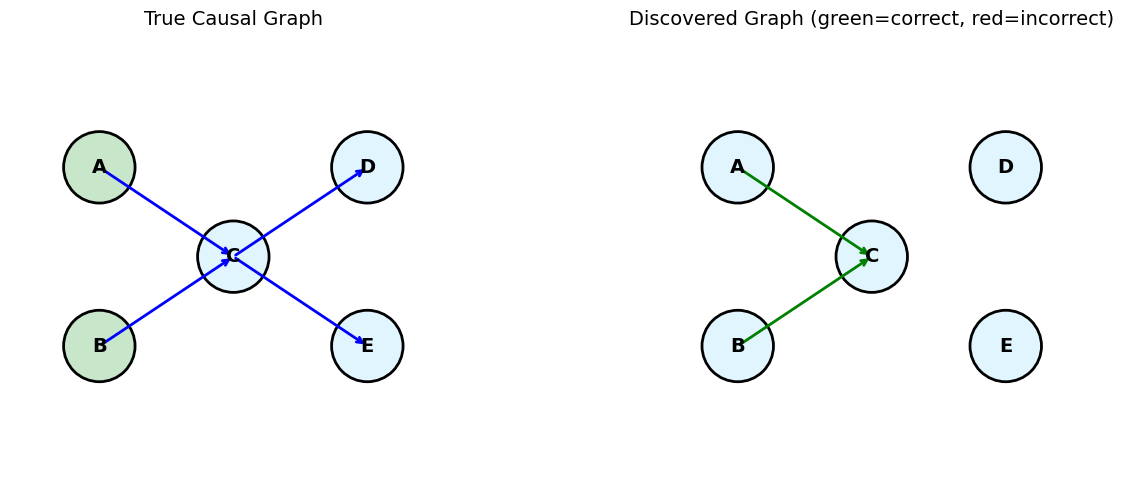

In [71]:
# Visualize discovered vs true graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

positions = {
    'A': (0.2, 0.7),
    'B': (0.2, 0.3),
    'C': (0.5, 0.5),
    'D': (0.8, 0.7),
    'E': (0.8, 0.3),
}

# True graph
ax1 = axes[0]
true_edge_list = [('A', 'C'), ('B', 'C'), ('C', 'D'), ('C', 'E')]
for src, dst in true_edge_list:
    ax1.annotate('', xy=positions[dst], xytext=positions[src],
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

for var, pos in positions.items():
    color = '#c8e6c9' if not true_edges[var] else '#e1f5fe'
    circle = plt.Circle(pos, 0.08, facecolor=color, edgecolor='black', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(pos[0], pos[1], var, ha='center', va='center', fontsize=14, fontweight='bold')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('True Causal Graph', fontsize=14)

# Discovered graph
ax2 = axes[1]
for child, parents in best_graph.edges.items():
    for parent in parents:
        is_correct = parent in true_edges.get(child, [])
        color = 'green' if is_correct else 'red'
        ax2.annotate('', xy=positions[child], xytext=positions[parent],
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))

for var, pos in positions.items():
    circle = plt.Circle(pos, 0.08, facecolor='#e1f5fe', edgecolor='black', linewidth=2)
    ax2.add_patch(circle)
    ax2.text(pos[0], pos[1], var, ha='center', va='center', fontsize=14, fontweight='bold')

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Discovered Graph (green=correct, red=incorrect)', fontsize=14)

plt.tight_layout()
plt.show()

## Part 13: Convergence Visualization (FR-015)

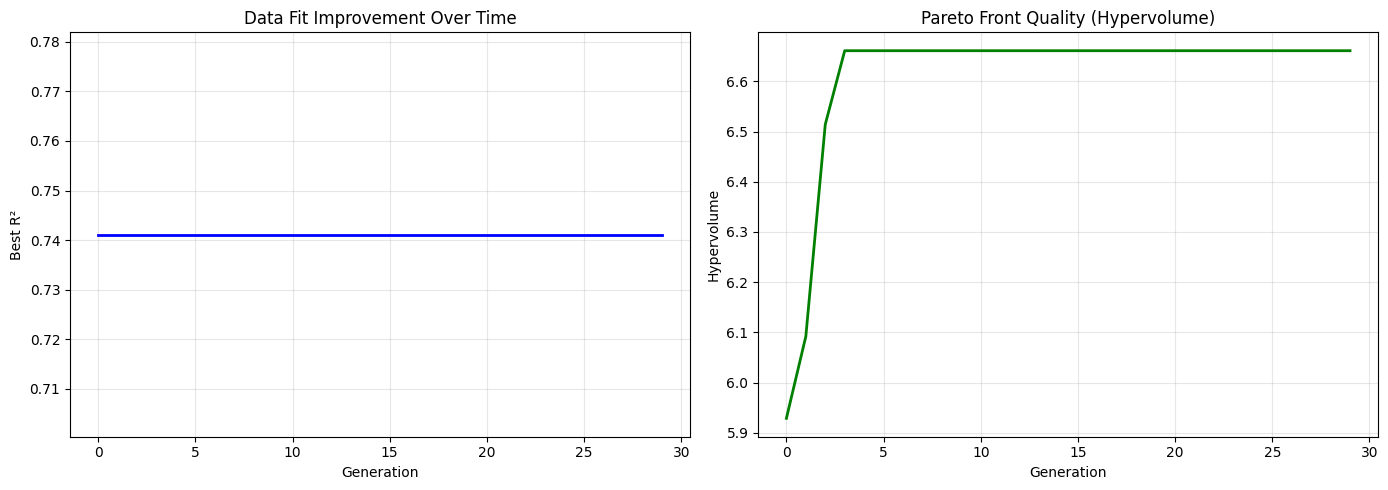

In [72]:
# Plot evolution history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

generations = range(len(evolver.history['best_r2']))

# Best R² over time
axes[0].plot(generations, evolver.history['best_r2'], 'b-', linewidth=2)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best R²')
axes[0].set_title('Data Fit Improvement Over Time')
axes[0].grid(True, alpha=0.3)

# Hypervolume over time
axes[1].plot(generations, evolver.history['hypervolume'], 'green', linewidth=2)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Hypervolume')
axes[1].set_title('Pareto Front Quality (Hypervolume)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 14: Callbacks (FR-017)

In [73]:
class MOCallback:
    """Base callback for multi-objective evolution."""
    def on_generation_end(self, generation: int, pareto_front: List[Any], 
                          hypervolume: float):
        pass
    
    def should_stop(self) -> bool:
        return False

class HypervolumeConvergenceCallback(MOCallback):
    """Stop when hypervolume stops improving."""
    def __init__(self, patience: int = 10, min_improvement: float = 0.01):
        self.patience = patience
        self.min_improvement = min_improvement
        self.best_hv = -float('inf')
        self.no_improvement_count = 0
        self._should_stop = False
    
    def on_generation_end(self, generation, pareto_front, hypervolume):
        if hypervolume > self.best_hv * (1 + self.min_improvement):
            self.best_hv = hypervolume
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
        
        if self.no_improvement_count >= self.patience:
            print(f"\n⏹️ Early stopping: No HV improvement for {self.patience} generations")
            self._should_stop = True
    
    def should_stop(self):
        return self._should_stop

print("✅ Multi-Objective Callbacks defined")

✅ Multi-Objective Callbacks defined


## Part 15: Checkpointing (FR-018)

In [74]:
import json

def save_pareto_checkpoint(pareto_graphs: List[CausalGraph], generation: int, path: str):
    """Save Pareto front checkpoint."""
    checkpoint = {
        'generation': generation,
        'pareto_front': [
            {
                'variables': g.variables,
                'edges': {k: list(v) for k, v in g.edges.items()},
                'coefficients': {f"{k[0]}->{k[1]}": v for k, v in g.coefficients.items()},
            }
            for g in pareto_graphs
        ],
    }
    with open(path, 'w') as f:
        json.dump(checkpoint, f, indent=2)
    print(f"💾 Pareto checkpoint saved to {path}")

def load_pareto_checkpoint(path: str) -> Tuple[List[CausalGraph], int]:
    """Load Pareto front checkpoint."""
    with open(path, 'r') as f:
        checkpoint = json.load(f)
    
    graphs = []
    for g_dict in checkpoint['pareto_front']:
        coefficients = {}
        for key, val in g_dict['coefficients'].items():
            parts = key.split('->')
            coefficients[(parts[0], parts[1])] = val
        
        graphs.append(CausalGraph(
            variables=g_dict['variables'],
            edges={k: list(v) for k, v in g_dict['edges'].items()},
            coefficients=coefficients,
        ))
    
    print(f"📂 Pareto checkpoint loaded: Generation {checkpoint['generation']}, {len(graphs)} solutions")
    return graphs, checkpoint['generation']

# Demonstrate
with tempfile.TemporaryDirectory() as tmpdir:
    ckpt_path = os.path.join(tmpdir, 'pareto_checkpoint.json')
    
    save_pareto_checkpoint(pareto_graphs, len(evolver.history['best_r2']), ckpt_path)
    
    loaded_graphs, loaded_gen = load_pareto_checkpoint(ckpt_path)
    print(f"   Loaded {len(loaded_graphs)} Pareto-optimal graphs")

💾 Pareto checkpoint saved to /var/folders/_p/9l79gq556sn9ngc796nx7tn40000gn/T/tmph5i9np43/pareto_checkpoint.json
📂 Pareto checkpoint loaded: Generation 30, 45 solutions
   Loaded 45 Pareto-optimal graphs


## Part 16: Island Model (FR-020, FR-021, FR-022, FR-023)

In [75]:
print("🏝️ Island Model for Multi-Objective Optimization")
print("=" * 50)
print("\nBenefits for NSGA-II:")
print("   1. Each island maintains its own Pareto front")
print("   2. Migration shares non-dominated solutions")
print("   3. Better coverage of the Pareto front")
print("   4. Prevents crowding collapse on islands")
print("\nTypical setup: 4 islands with different selection pressure")

island_config = create_island_config(
    num_islands=4,
    population_per_island=30,
    topology="ring",
    migration_rate=0.1,
    migration_interval=5
)

print(f"\n📊 Island Configuration:")
print(f"   Islands: {island_config.num_islands}")
print(f"   Total population: {island_config.total_population}")
print(f"   Migration: top {island_config.migration_rate:.0%} every {island_config.migration_interval} generations")

🏝️ Island Model for Multi-Objective Optimization

Benefits for NSGA-II:
   1. Each island maintains its own Pareto front
   2. Migration shares non-dominated solutions
   3. Better coverage of the Pareto front
   4. Prevents crowding collapse on islands

Typical setup: 4 islands with different selection pressure

📊 Island Configuration:
   Islands: 4
   Total population: 120
   Migration: top 10% every 5 generations


## Part 17: GPU Acceleration (FR-024, FR-025, FR-026)

In [76]:
gpu_info = check_gpu_available()

print("🖥️ GPU Acceleration for Multi-Objective")
print("=" * 50)
print(f"GPU Available: {gpu_info['available']}")
print(f"Info: {gpu_info['message'] or 'CPU-only mode'}")

print("\n📊 What GPU can accelerate:")
print("   ✓ Fitness evaluation (linear regression)")
print("   ✓ Dominance comparison (parallel pairwise)")
print("   ✓ Crowding distance calculation")
print("   ✗ Non-dominated sorting (sequential by nature)")

if not gpu_info['available']:
    print("\nℹ️ CPU is sufficient for moderate problem sizes.")
    print("   GPU helps with large populations (500+) or expensive fitness functions.")

🖥️ GPU Acceleration for Multi-Objective
GPU Available: False
Info: No GPU detected. Running in CPU mode.
GPU sections will show placeholder benchmarks.
Install PyTorch CUDA or JAX with GPU support for acceleration.

📊 What GPU can accelerate:
   ✓ Fitness evaluation (linear regression)
   ✓ Dominance comparison (parallel pairwise)
   ✓ Crowding distance calculation
   ✗ Non-dominated sorting (sequential by nature)

ℹ️ CPU is sufficient for moderate problem sizes.
   GPU helps with large populations (500+) or expensive fitness functions.


## Part 18: Extensions & Next Steps (FR-019)

In [77]:
print("📚 What You've Learned:")
print("=" * 50)
print("1. Pareto dominance for comparing multi-objective solutions")
print("2. NSGA-II: non-dominated sorting + crowding distance")
print("3. Three objectives for causal discovery: fit, sparsity, simplicity")
print("4. Pareto front gives full trade-off curve, not just one solution")
print("5. Hypervolume measures Pareto front quality")

print("\n🔬 Experiment Ideas:")
experiments = [
    ("Add more objectives", "e.g., acyclicity penalty, identifiability"),
    ("Try larger graphs", "10+ variables with more complex structure"),
    ("Compare algorithms", "MOEA/D, SMS-EMOA vs NSGA-II"),
    ("Add latent variables", "Discover hidden confounders (FR-053)"),
    ("Real data", "Apply to observational datasets"),
]
for exp, note in experiments:
    print(f"   • {exp}")
    print(f"     {note}")

📚 What You've Learned:
1. Pareto dominance for comparing multi-objective solutions
2. NSGA-II: non-dominated sorting + crowding distance
3. Three objectives for causal discovery: fit, sparsity, simplicity
4. Pareto front gives full trade-off curve, not just one solution
5. Hypervolume measures Pareto front quality

🔬 Experiment Ideas:
   • Add more objectives
     e.g., acyclicity penalty, identifiability
   • Try larger graphs
     10+ variables with more complex structure
   • Compare algorithms
     MOEA/D, SMS-EMOA vs NSGA-II
   • Add latent variables
     Discover hidden confounders (FR-053)
   • Real data
     Apply to observational datasets


In [78]:
print("\n📚 Complete Tutorial Series:")
print("=" * 50)

tutorials = [
    ("Tutorial 01", "VectorGenome", "Continuous optimization, function benchmarks"),
    ("Tutorial 02", "SequenceGenome", "Genetic programming, symbolic regression"),
    ("Tutorial 03", "GraphGenome/NEAT", "Network topology evolution, XOR"),
    ("Tutorial 04", "RL/Neuroevolution", "Policy evolution, CartPole"),
    ("Tutorial 05", "SCM/Multi-Objective", "Causal discovery, NSGA-II"),
]

for tutorial, genome, description in tutorials:
    check = "✓" if tutorial == "Tutorial 05" else " "
    print(f"   [{check}] {tutorial}: {genome}")
    print(f"       {description}\n")


📚 Complete Tutorial Series:
   [ ] Tutorial 01: VectorGenome
       Continuous optimization, function benchmarks

   [ ] Tutorial 02: SequenceGenome
       Genetic programming, symbolic regression

   [ ] Tutorial 03: GraphGenome/NEAT
       Network topology evolution, XOR

   [ ] Tutorial 04: RL/Neuroevolution
       Policy evolution, CartPole

   [✓] Tutorial 05: SCM/Multi-Objective
       Causal discovery, NSGA-II



## Summary

| Concept | ML Analogy | Key Insight |
|---------|------------|-------------|
| **Pareto Dominance** | Multi-task comparison | Better on ALL metrics |
| **Non-dominated Sorting** | Ranking | Assign solutions to fronts |
| **Crowding Distance** | Diversity regularization | Preserve isolated solutions |
| **Hypervolume** | Quality metric | Measure Pareto front coverage |
| **Weighted-Sum** | Scalarization | Combines into single objective |

**Key Insight**: Multi-objective optimization finds the trade-off curve - you decide which solution to use AFTER evolution!